In [1]:
!pip install wikipedia-api

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia-api: filename=Wikipedia_API-0.8.1-py3-none-any.whl size=15383 sha256=470ffc1fd30de94a26f58913a2ab5b5c04fa957266800cdb14e41056421008dc
  Stored in directory: /root/.cache/pip/wheels/33/3c/79/b36253689d838af4a0539782853ac3cc38a83a6591ad570dde
Successfully built wikipedia-api


In [2]:
import numpy as np
import tensorflow as tf
import wikipediaapi
import warnings
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
warnings.filterwarnings("ignore")

In [3]:
def fetch_wikipedia_text(topic):
      wiki_wiki = wikipediaapi.Wikipedia(
      language='en',
      extract_format=wikipediaapi.ExtractFormat.WIKI,
      user_agent='my-application/1.0')
      page = wiki_wiki.page(topic)
      return page.text

def preprocess_text(text):
    text = text.lower()
    text = ''.join(c for c in text if c.isalnum() or c in [' ', '\n'])
    return text

In [4]:
topic = "Deep sea"
wikipedia_text = fetch_wikipedia_text(topic)
preprocessed_text = preprocess_text(wikipedia_text)
print(preprocessed_text)

the deep sea is broadly defined as the ocean depth where light begins to fade at an approximate depth of 200 m 660 ft or the point of transition from continental shelves to continental slopes conditions within the deep sea are a combination of low temperatures darkness and high pressure the deep sea is considered the least explored earth biome as the extreme conditions make the environment difficult to access and explore
organisms living within the deep sea have a variety of adaptations to survive in these conditions organisms can survive in the deep sea through a number of feeding methods including scavenging predation and filtration with a number of organisms surviving by feeding on marine snow marine snow is organic material that has fallen from upper waters into the deep sea
in 1960 the bathyscaphe trieste descended to the bottom of the mariana trench near guam at 10911 m 35797 ft 6780 mi the deepest known spot in any ocean if mount everest 8848 m or 29029 ft or 5498 mi were submer

In [5]:
text = preprocessed_text
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
encoded = tokenizer.texts_to_sequences([text])[0]
vocab_size = len(tokenizer.word_index) + 1

seq_length = 100
sequences = []
for i in range(seq_length, len(encoded)):
    seq = encoded[i-seq_length:i+1]
    sequences.append(seq)

sequences = np.array(sequences)
X, y = sequences[:,:-1], sequences[:,-1]
y = to_categorical(y, num_classes=vocab_size)

In [6]:
model = Sequential([
    Embedding(vocab_size, 50, input_length=seq_length),
    LSTM(150, return_sequences=True),
    LSTM(100),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, y, epochs=100,callbacks=[tf.keras.callbacks.ReduceLROnPlateau()])

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.0526 - loss: 6.5444 - learning_rate: 0.0010
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0696 - loss: 6.0145 - learning_rate: 0.0010
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0717 - loss: 5.9437 - learning_rate: 0.0010
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0707 - loss: 5.9562 - learning_rate: 0.0010
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0710 - loss: 5.8867 - learning_rate: 0.0010
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0692 - loss: 5.7811 - learning_rate: 0.0010
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0696 - loss: 5.6662 - learning_rate: 0.0010
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0788 - loss: 5.5350 - learning_rate: 0.0010
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0765 - loss: 5.5438 - learning_rate: 0.0010
Epoch 10/1

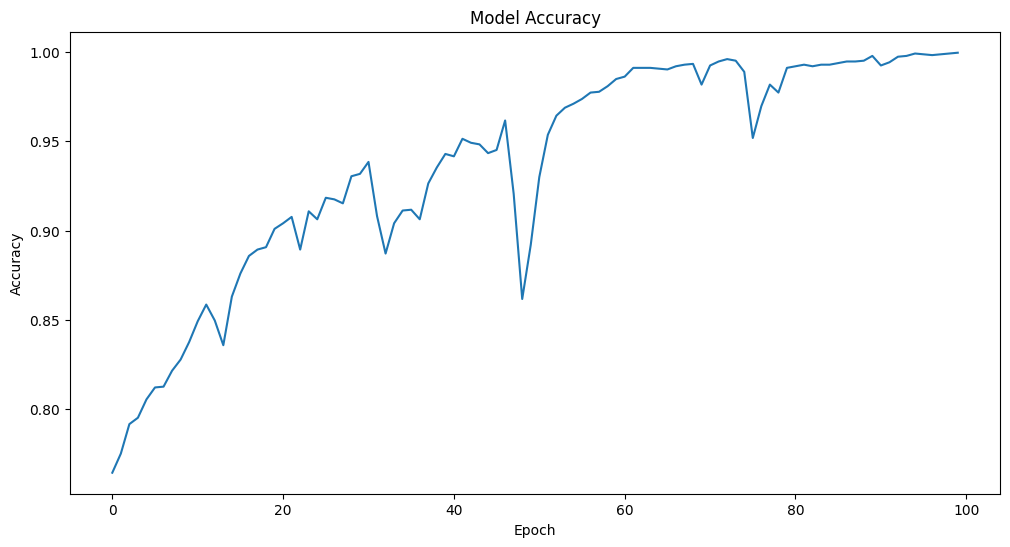

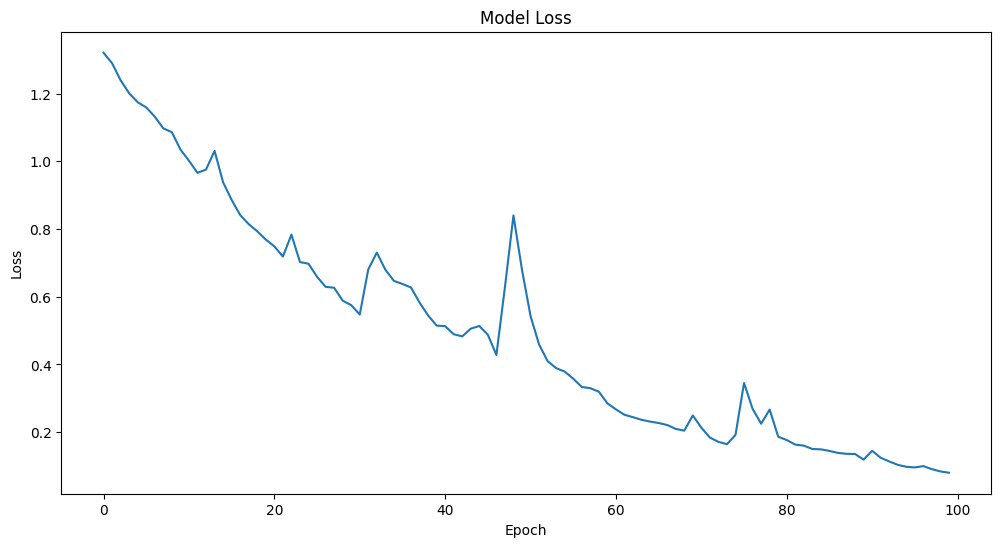

In [9]:
import matplotlib.pyplot as plt
history = model.fit(X, y, epochs=100, callbacks=[tf.keras.callbacks.ReduceLROnPlateau()], verbose=0)

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [7]:
def generate_text_base_word(model, tokenizer, seed_text, num_words):
    result = []
    in_text = seed_text
    for _ in range(num_words):
        encoded = tokenizer.texts_to_sequences([in_text])[0]
        encoded = pad_sequences([encoded], maxlen=seq_length, truncating='pre')
        yhat = model.predict(encoded, verbose=0)
        yhat = np.argmax(yhat, axis=1)
        out_word = ''
        for word, index in tokenizer.word_index.items():
            if index == yhat:
                out_word = word
                break
        in_text += ' ' + out_word
        result.append(out_word)
    return ' '.join(result)

In [8]:
seed_text = "Deep sea"
generated_text = generate_text_base_word(model, tokenizer, seed_text, 100)
print(seed_text,generated_text)

Deep sea foraminifera a osmolytes and assembly and assembly and assembly and assembly and assembly and assembly and assembly and assembly and assembly and assembly and assembly and assembly and assembly and assembly and assembly and assembly and assembly of a fiber in their buoyancy many deepsea species have jellylike flesh consisting mostly of glycosaminoglycans the gelatinous external links deep sea foraminifera deep sea foraminifera deep sea foraminifera deep sea foraminifera deep sea foraminifera deep sea foraminifera deep sea foraminifera deep sea foraminifera deep sea foraminifera deep sea foraminifera deep sea foraminifera deep sea organisms have developed adaptations to 39 substitution 4143
